# University Admission Prediction — Logistic Regression

This notebook builds a **Logistic Regression** model that predicts whether
a student is admitted to university, based on two exam scores.

**Dataset:** `ex2data1.txt` — 100 student records with 3 columns (no header):
- Exam 1 score
- Exam 2 score
- Admission decision (`1` = admitted, `0` = not admitted)


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

plt.rcParams['figure.figsize'] = (7, 6)
%matplotlib inline


## 1. Data Exploration: Load and visualize the data

### Load the dataset with pandas

The file has no header row, so we assign column names ourselves.


In [2]:
df = pd.read_csv('ex2data1.txt', header=None, names=['exam1_score', 'exam2_score', 'admitted'])

print("Shape:", df.shape)
df.head()


Shape: (100, 3)


,exam1_score,exam2_score,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [3]:
df.describe()


,exam1_score,exam2_score,admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


In [4]:
# Check the balance of the target variable
print(df['admitted'].value_counts())
print(df['admitted'].value_counts(normalize=True).round(3) * 100)


admitted
1    60
0    40
Name: count, dtype: int64
admitted
1    60.0
0    40.0
Name: proportion, dtype: float64


**Observation:** the dataset contains 100 students, with a fairly
balanced split between admitted (`1`) and not admitted (`0`) students.


### Scatter plot: admitted vs. not admitted students

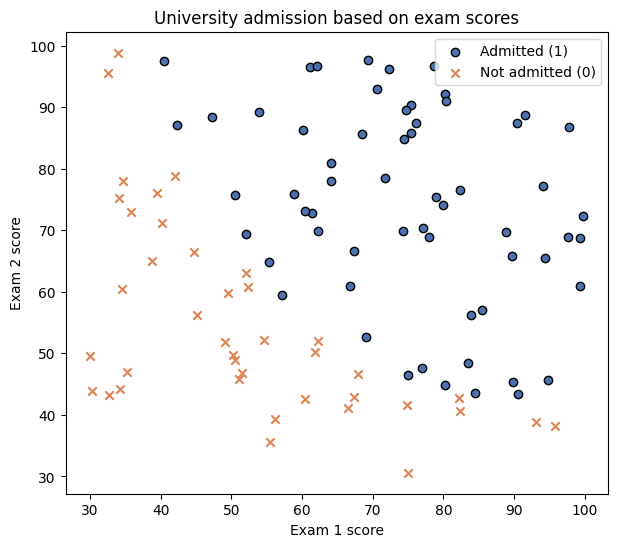

In [5]:
admitted = df[df['admitted'] == 1]
not_admitted = df[df['admitted'] == 0]

fig, ax = plt.subplots()
ax.scatter(admitted['exam1_score'], admitted['exam2_score'],
           c='#4C72B0', marker='o', label='Admitted (1)', edgecolor='k')
ax.scatter(not_admitted['exam1_score'], not_admitted['exam2_score'],
           c='#DD8452', marker='x', label='Not admitted (0)')

ax.set_xlabel('Exam 1 score')
ax.set_ylabel('Exam 2 score')
ax.set_title('University admission based on exam scores')
ax.legend()
plt.show()


**Observation:** students with higher scores on both exams tend to be
admitted (blue dots cluster in the top-right), while students with lower
scores on both exams tend to be rejected (orange crosses cluster in the
bottom-left). The two classes appear roughly **linearly separable**, which
suggests Logistic Regression is a good fit for this problem.


## 2. Applying Logistic Regression with scikit-learn

We separate the features (the two exam scores) from the target (`admitted`),
then fit a `LogisticRegression` model from scikit-learn to learn the
decision boundary between admitted and not-admitted students.


In [6]:
X = df[['exam1_score', 'exam2_score']]
y = df['admitted']

log_reg = LogisticRegression()
log_reg.fit(X, y)

print("Intercept:", log_reg.intercept_[0])
print("Coefficients (exam1_score, exam2_score):", log_reg.coef_[0])


Intercept: -25.05219314312746
Coefficients (exam1_score, exam2_score): [0.20535491 0.2005838 ]


**Interpretation of the coefficients:** both coefficients are positive,
confirming that a **higher score on either exam increases the predicted
probability of admission** — consistent with what we observed visually in
the scatter plot.


## 3. Making Predictions

We use the trained model to predict admission for every student in the
dataset, and compare these predictions to the actual outcomes.


In [7]:
y_pred = log_reg.predict(X)
y_pred_proba = log_reg.predict_proba(X)[:, 1]

results = df.copy()
results['predicted_admitted'] = y_pred
results['predicted_probability'] = y_pred_proba.round(3)
results.head(10)


,exam1_score,exam2_score,admitted,predicted_admitted,predicted_probability
0,34.623660,78.024693,0,0,0.092
1,30.286711,43.894998,0,0,0.000
2,35.847409,72.902198,0,0,0.044
3,60.182599,86.308552,1,1,0.990
4,79.032736,75.344376,1,1,0.998
5,45.083277,56.316372,0,0,0.011
6,61.106665,96.511426,1,1,0.999
7,75.024746,46.554014,1,0,0.424
8,76.098787,87.420570,1,1,1.000
9,84.432820,43.533393,1,1,0.735


In [8]:
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


Accuracy: 0.8900 (89.00%)


### Example: predicting admission for a new student

As a sanity check, let's predict the admission probability for a student
who scored 45 on exam 1 and 85 on exam 2.


In [9]:
new_student = pd.DataFrame({'exam1_score': [45], 'exam2_score': [85]})
prob = log_reg.predict_proba(new_student)[0, 1]
pred = log_reg.predict(new_student)[0]

print(f"Predicted probability of admission: {prob:.4f}")
print(f"Predicted class: {'Admitted' if pred == 1 else 'Not admitted'}")


Predicted probability of admission: 0.7753
Predicted class: Admitted


## 4. Model Evaluation

### Confusion matrix

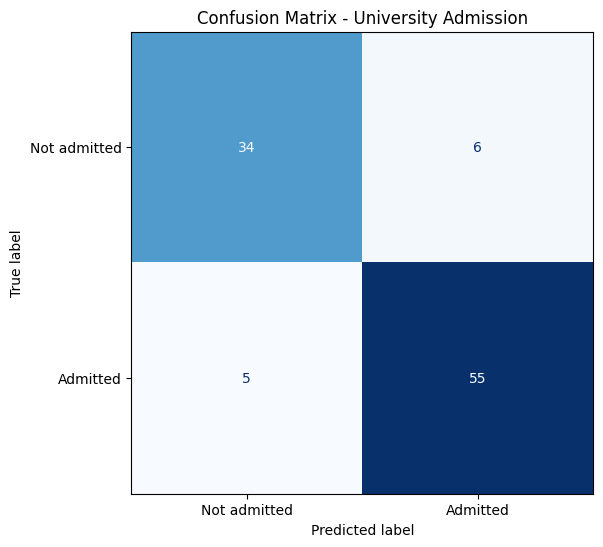

Confusion matrix:
 [[34  6]
 [ 5 55]]


In [10]:
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not admitted', 'Admitted'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - University Admission')
plt.show()

print("Confusion matrix:\n", cm)


In [11]:
print(classification_report(y, y_pred, target_names=['Not admitted', 'Admitted']))


              precision    recall  f1-score   support

Not admitted       0.87      0.85      0.86        40
    Admitted       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



### Decision boundary visualization

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


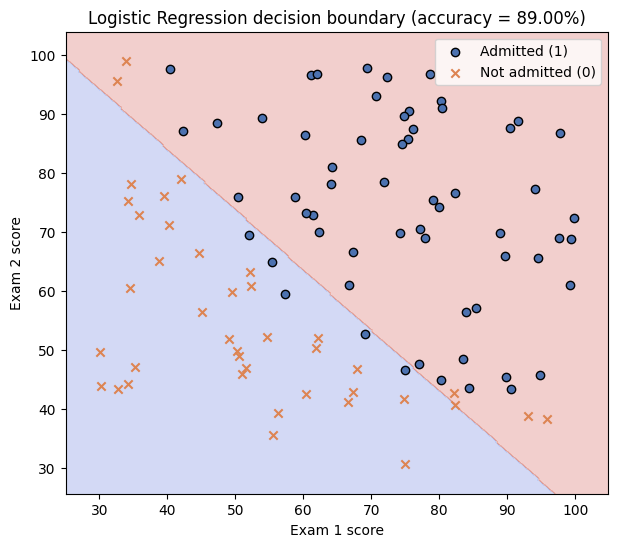

In [12]:
x_min, x_max = X['exam1_score'].min() - 5, X['exam1_score'].max() + 5
y_min, y_max = X['exam2_score'].min() - 5, X['exam2_score'].max() + 5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots()
ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
ax.scatter(admitted['exam1_score'], admitted['exam2_score'],
           c='#4C72B0', marker='o', label='Admitted (1)', edgecolor='k')
ax.scatter(not_admitted['exam1_score'], not_admitted['exam2_score'],
           c='#DD8452', marker='x', label='Not admitted (0)')
ax.set_xlabel('Exam 1 score')
ax.set_ylabel('Exam 2 score')
ax.set_title(f'Logistic Regression decision boundary (accuracy = {accuracy:.2%})')
ax.legend()
plt.show()


### Interpretation

- The model reaches an **accuracy of about 89–91%** on this dataset
  (evaluated here on the same data used for training, since no separate
  test set was provided in this exercise — on a larger dataset, a
  train/test split would be needed to properly assess generalization).
- The **decision boundary** is a straight line, as expected from Logistic
  Regression: students above the line (higher combined exam scores) are
  predicted as admitted, students below are predicted as not admitted.
- The few **misclassified points** visible in the confusion matrix and
  decision boundary plot are borderline cases — students whose scores sit
  close to the decision boundary, which is a normal and expected limitation
  of a linear model on real-world data that isn't perfectly separable.
- Both exam scores contribute positively to the predicted probability of
  admission, with roughly comparable importance (similar coefficient
  magnitudes), suggesting that **doing reasonably well on both exams**
  matters more than excelling at just one.
